In [1]:
from __future__ import print_function, unicode_literals, absolute_import, division
import numpy as np
import matplotlib.pyplot as plt
from tifffile import imread
from csbdeep.utils import axes_dict, plot_some, plot_history
from csbdeep.utils.tf import limit_gpu_memory
from csbdeep.io import load_training_data
from csbdeep.models import Config, CARE

I0000 00:00:1758515772.943437   31856 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1758515773.429345   31856 cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1758515775.097133   31856 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
(X,Y), (X_val,Y_val), axes = load_training_data('patches_data.npz', validation_split=0.1, verbose=True)

c = axes_dict(axes)['C']
n_channel_in, n_channel_out = X.shape[c], Y.shape[c]

number of training images:	 7023
number of validation images:	 780
image size (3D):		 (96, 32, 32)
axes:				 SZYXC
channels in / out:		 1 / 1


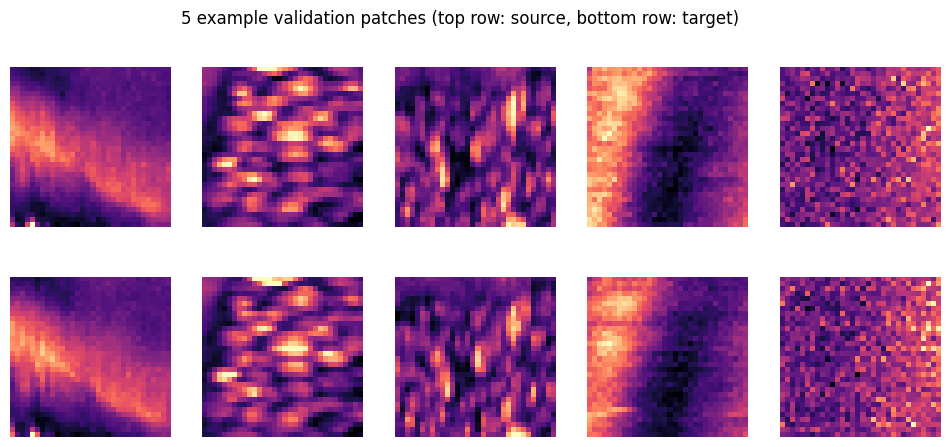

In [3]:
plt.figure(figsize=(12,5))
plot_some(X_val[:5],Y_val[:5])
plt.suptitle('5 example validation patches (top row: source, bottom row: target)');

In [4]:
config = Config(
    axes= axes,                # 3D with channel-last
    n_channel_in=1,
    n_channel_out=1,
    probabilistic=False,
    unet_residual=True,
    unet_n_depth=2,
    unet_kern_size=3,
    unet_n_first=32,
    train_epochs=30,
    train_steps_per_epoch=100,
)
print(config)
vars(config)

Config(n_dim=3, axes='ZYXC', n_channel_in=1, n_channel_out=1, train_checkpoint='weights_best.h5', train_checkpoint_last='weights_last.h5', train_checkpoint_epoch='weights_now.h5', probabilistic=False, unet_residual=True, unet_n_depth=2, unet_kern_size=3, unet_n_first=32, unet_last_activation='linear', unet_input_shape=(None, None, None, 1), train_loss='mae', train_epochs=30, train_steps_per_epoch=100, train_learning_rate=0.0004, train_batch_size=16, train_tensorboard=True, train_reduce_lr={'factor': 0.5, 'patience': 10, 'min_delta': 0})


{'n_dim': 3,
 'axes': 'ZYXC',
 'n_channel_in': 1,
 'n_channel_out': 1,
 'train_checkpoint': 'weights_best.h5',
 'train_checkpoint_last': 'weights_last.h5',
 'train_checkpoint_epoch': 'weights_now.h5',
 'probabilistic': False,
 'unet_residual': True,
 'unet_n_depth': 2,
 'unet_kern_size': 3,
 'unet_n_first': 32,
 'unet_last_activation': 'linear',
 'unet_input_shape': (None, None, None, 1),
 'train_loss': 'mae',
 'train_epochs': 30,
 'train_steps_per_epoch': 100,
 'train_learning_rate': 0.0004,
 'train_batch_size': 16,
 'train_tensorboard': True,
 'train_reduce_lr': {'factor': 0.5, 'patience': 10, 'min_delta': 0}}

In [5]:
model = CARE(config, 'my_model', basedir='models')

/opt/venv/lib/python3.11/site-packages/csbdeep/models/base_model.py:203: UserWarning: output path for model already exists, files may be overwritten: /workspace/BCARS_N2N/models/my_model
  warnings.warn('output path for model already exists, files may be overwritten: %s' % str(self.logdir.resolve()))
W0000 00:00:1758515789.403369   31856 gpu_device.cc:2456] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1758515789.408057   31856 gpu_device.cc:2456] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1758515789.631626   31856 gpu_device.cc:2040] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 29041 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5090, pci bus id: 0000:01:00.0, compute capability

In [6]:
history = model.train(X,Y, validation_data=(X_val,Y_val))

Epoch 1/30


I0000 00:00:1758515793.346409   33000 service.cc:158] XLA service 0x6ff8bc01aca0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1758515793.346441   33000 service.cc:166]   StreamExecutor device (0): NVIDIA GeForce RTX 5090, Compute Capability 12.0a
I0000 00:00:1758515793.422264   33000 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1758515793.705982   33000 cuda_dnn.cc:463] Loaded cuDNN version 91002


  2/100 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - loss: 0.0815 - mae: 0.0815 - mse: 0.0132 

I0000 00:00:1758515800.419818   33000 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.0588 - mae: 0.0588 - mse: 0.0080

/opt/venv/lib/python3.11/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input
Received: inputs=('Tensor(shape=(1, 96, 32, 32, 1))',)
  warnings.warn(msg)


100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 123ms/step - loss: 0.0546 - mae: 0.0546 - mse: 0.0069 - val_loss: 0.0506 - val_mae: 0.0506 - val_mse: 0.0058 - learning_rate: 4.0000e-04
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 65ms/step - loss: 0.0516 - mae: 0.0516 - mse: 0.0061 - val_loss: 0.0495 - val_mae: 0.0495 - val_mse: 0.0056 - learning_rate: 4.0000e-04
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - loss: 0.0508 - mae: 0.0508 - mse: 0.0058 - val_loss: 0.0494 - val_mae: 0.0494 - val_mse: 0.0055 - learning_rate: 4.0000e-04
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 65ms/step - loss: 0.0501 - mae: 0.0501 - mse: 0.0058 - val_loss: 0.0491 - val_mae: 0.0491 - val_mse: 0.0055 - learning_rate: 4.0000e-04
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - loss: 0.0510 - mae: 0.0510 - mse: 0.0058 - val_loss: 0.0491 - val_mae: 0.0491 - val_mse: 0.0054 - learning_rate: 4.0000e-04
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - loss: 0.0497 - mae: 0.0497 - mse: 0.0057 - val_loss: 0.0490

['learning_rate', 'loss', 'mae', 'mse', 'val_loss', 'val_mae', 'val_mse']


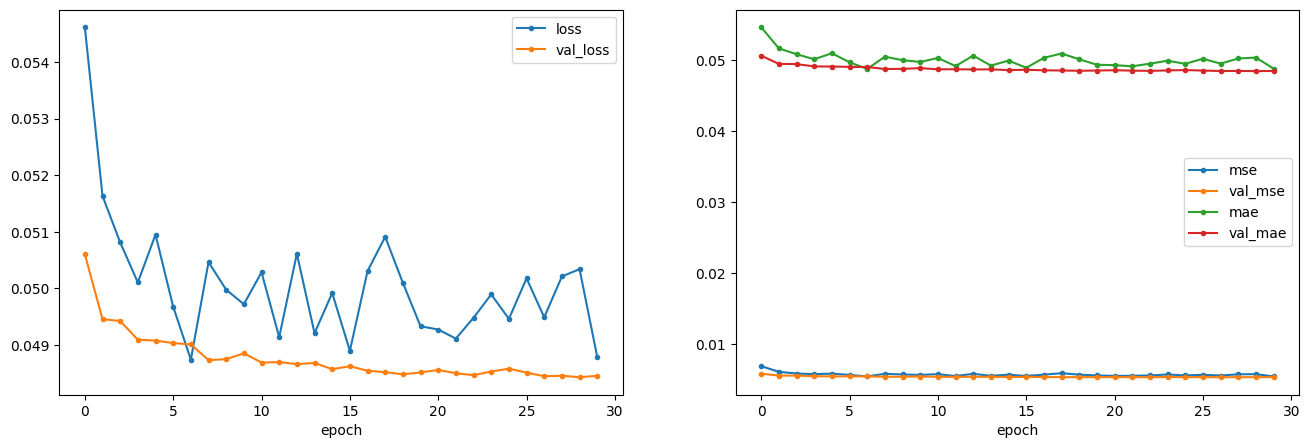

In [7]:
print(sorted(list(history.history.keys())))
plt.figure(figsize=(16,5))
plot_history(history,['loss','val_loss'],['mse','val_mse','mae','val_mae']);

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 959ms/step


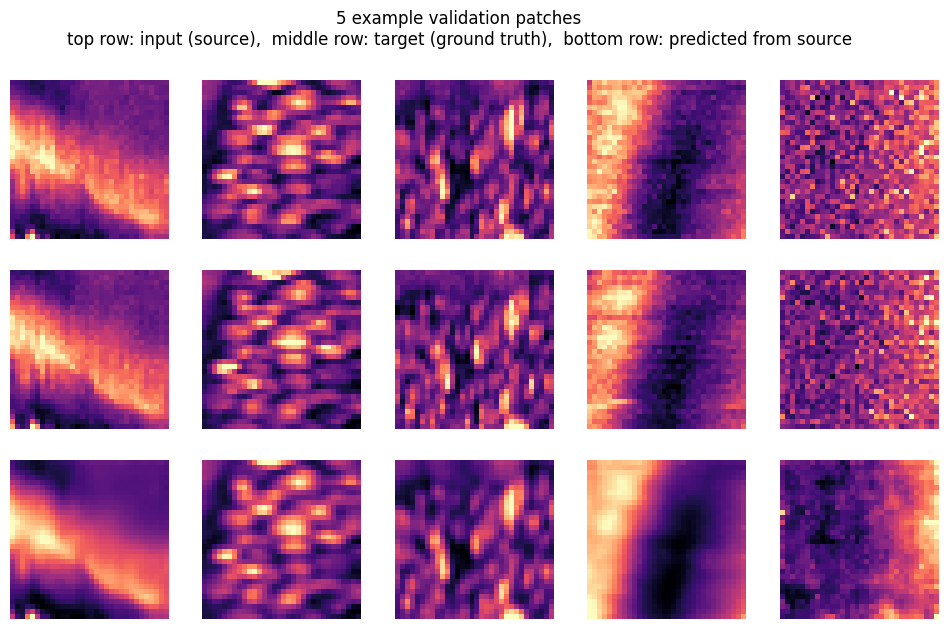

In [8]:
plt.figure(figsize=(12,7))
_P = model.keras_model.predict(X_val[:5])
if config.probabilistic:
    _P = _P[...,:(_P.shape[-1]//2)]
plot_some(X_val[:5],Y_val[:5],_P,pmax=99.5)
plt.suptitle('5 example validation patches\n'      
             'top row: input (source),  '          
             'middle row: target (ground truth),  '
             'bottom row: predicted from source');

In [11]:
print(_P.shape)

(5, 32, 96, 96, 1)
